In [1]:
import os
import polars as pl
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [2]:
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/08_HepG2/'

In [3]:
def load_data(path):
    gene_pl = pd.read_parquet(path)
    return gene_pl

In [4]:
def reformat_data(df, columns):
    processed_arrays = []

    for col in columns:
        stacked = np.vstack(df[col].values)
        processed_arrays.append(stacked)

    X = np.hstack(processed_arrays)
    return X

In [24]:
# Create histogram with 4 buckets
def create_histogram(df, column, bins=4):
    
    # Plot the histogram using Matplotlib
    plt.figure(figsize=(10, 6))
    df[column].hist(bins=bins, edgecolor='black')
    plt.title(f'Histogram of {column} ({bins} Buckets)')
    plt.xlabel(column)
    plt.yscale("log")
    plt.ylabel('Frequency')
    plt.show()

In [10]:
def create_bucket_table(df, column, bins=4):
    # Create histogram with number of bins
    hist, bin_edges = np.histogram(df[column], bins=bins)
    
    # Create a DataFrame to display the bucket information
    bucket_table = pd.DataFrame({
        'Bucket Start': bin_edges[:-1],
        'Bucket End': bin_edges[1:],
        'Frequency': hist
    })
    
    # Optional: Format the bucket ranges nicely
    bucket_table['Bucket Range'] = bucket_table.apply(
        lambda row: f'[{row["Bucket Start"]:.2f} - {row["Bucket End"]:.2f})', 
        axis=1
    )
    
    return bucket_table

# Data Loading

In [6]:
# Load dataset
gene_pl = load_data(os.path.join(WORKING_DIR, 'dataset', 'gene_w_label_value_1.parquet'))
gene_pl.head(5)

,gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label
0,XLOC_000001,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.000000,0
1,XLOC_000003,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.000000,0
2,XLOC_000006,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.088845,0
3,XLOC_000007,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,4.047430,1
4,XLOC_000008,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",6,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,26.793400,1


In [7]:
gene_pl["value_1"].describe()

count    22154.000000
mean        21.856847
std        167.605195
min          0.000000
25%          0.015560
50%          1.142095
75%         12.266025
max      12870.900000
Name: value_1, dtype: float64

In [15]:
gene_pl['value_1'].describe()

count    22154.000000
mean        21.856847
std        167.605195
min          0.000000
25%          0.015560
50%          1.142095
75%         12.266025
max      12870.900000
Name: value_1, dtype: float64

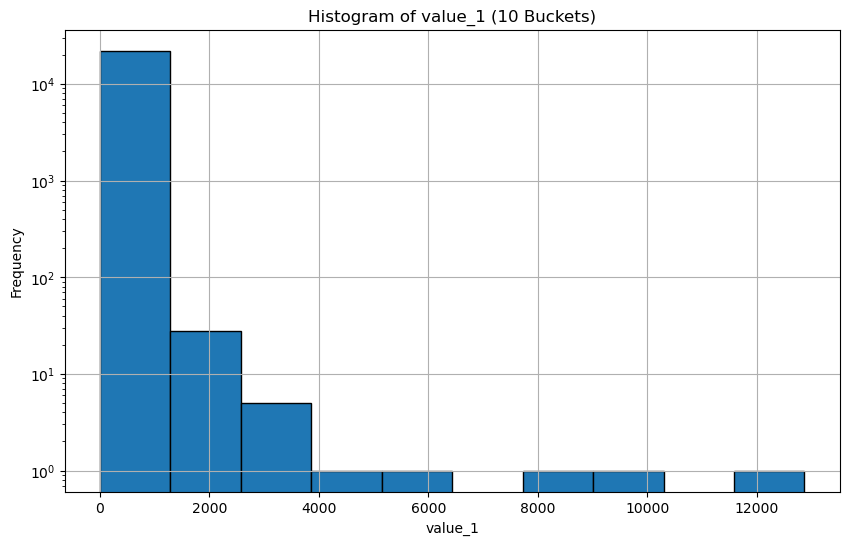

In [49]:
create_histogram(gene_pl, 'value_1', bins=10)

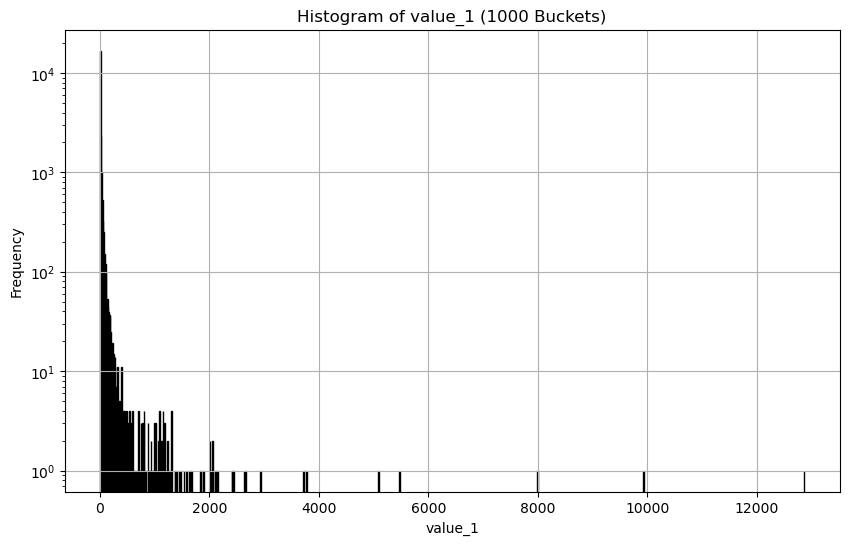

In [25]:
create_histogram(gene_pl, 'value_1', bins=1000)

In [17]:
bucket_table_10 = create_bucket_table(gene_pl, 'value_1', 10)
bucket_table_100 = create_bucket_table(gene_pl, 'value_1', 100)

# Print the table
print(bucket_table_10)
print(bucket_table_100)

   Bucket Start  Bucket End  Frequency           Bucket Range
0          0.00     1287.09      22116       [0.00 - 1287.09)
1       1287.09     2574.18         28    [1287.09 - 2574.18)
2       2574.18     3861.27          5    [2574.18 - 3861.27)
3       3861.27     5148.36          1    [3861.27 - 5148.36)
4       5148.36     6435.45          1    [5148.36 - 6435.45)
5       6435.45     7722.54          0    [6435.45 - 7722.54)
6       7722.54     9009.63          1    [7722.54 - 9009.63)
7       9009.63    10296.72          1   [9009.63 - 10296.72)
8      10296.72    11583.81          0  [10296.72 - 11583.81)
9      11583.81    12870.90          1  [11583.81 - 12870.90)
    Bucket Start  Bucket End  Frequency           Bucket Range
0          0.000     128.709      21624        [0.00 - 128.71)
1        128.709     257.418        299      [128.71 - 257.42)
2        257.418     386.127         67      [257.42 - 386.13)
3        386.127     514.836         36      [386.13 - 514.84)
4  

## Trying to do scaling by using RobustScaler

In [12]:
# Initialize RobustScaler
scaler = RobustScaler()

gene_pl['value_1_scaled'] = scaler.fit_transform(gene_pl[['value_1']])

In [ ]:
gene_pl.head(2)

In [ ]:
bucket_table = create_bucket_table(gene_pl, 'value_1_scaled', 10)
print(bucket_table)

# Data Preparation

## Data Transformation

In [26]:
markers = ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']
X = reformat_data(gene_pl, markers)

In [27]:
print(X)
print(X.shape)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(22154, 20000)


In [28]:
y = gene_pl['value_1'].values

In [29]:
print(y)
print(y.shape)

[0.        0.        0.0888452 ... 0.        0.        0.       ]
(22154,)


## Split train and test dataset

In [30]:
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(17723, 20000)
(4431, 20000)
(17723,)
(4431,)


# Modeling

In [32]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Testing

In [33]:
def calculate_metric(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mae = np.mean(np.abs(y_true, y_pred))
    # mae = mean_absolute_error(y_true, y_pred)

    return {
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'mae': mae
    }

In [34]:
# Get scores
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Train score: {train_score}")
print(f"Test score: {test_score}")

Train score: 0.7507847910989099
Test score: -1.5679481543655264e+21


In [35]:
y_train_pred = model.predict(X_train)
train_metric = calculate_metric(y_train, y_train_pred)
train_metric

{'mse': 8042.179820712976,
 'rmse': 89.67820148014218,
 'r2': 0.7507847910989099,
 'mae': 22.64126143270892}

In [36]:
y_test_pred = model.predict(X_test)
test_metric = calculate_metric(y_test, y_test_pred)
test_metric

{'mse': 1.7811459175872436e+25,
 'rmse': 4220362446031.435,
 'r2': -1.5679481543655264e+21,
 'mae': 18.7193645084789}

In [37]:
y_test

array([ 5.16245 ,  0.131845, 35.8993  , ...,  2.95333 ,  0.      ,
        2.91179 ])

In [38]:
y_test_pred

array([ 5.16245 ,  0.131845, 35.8993  , ...,  2.95333 ,  0.      ,
        2.91179 ])

In [39]:
print(r2_score(y_train, y_train_pred))
print(mean_absolute_error(y_train, y_train_pred))

1.0
0.0


In [40]:
print(r2_score(y_test, y_test_pred))
print(mean_absolute_error(y_test, y_test_pred))

1.0
0.0


# Plotting

In [41]:
def plotting(df, c1, c2):
    plt.figure(figsize=(10, 6))
    plt.scatter(df.index, df[c1], label=f"{c1}", marker='o',)
    plt.scatter(df.index, df[c2], label=f"{c2}", marker='x', alpha=0.5)
    
    plt.xlabel('Row Number')
    plt.ylabel('value_1')
    # plt.yscale('log', base=10)
    plt.title(f'{c1} vs {c2}')
    plt.legend()
    plt.grid(True)
    
    # Save the plot to a file
    # plt.savefig(f'img/{c1}_vs_{c2}.png')
    
    plt.show()

In [42]:
data = pd.DataFrame({'y_train': y_train, 'y_train_pred': y_train_pred})
data_test = pd.DataFrame({'y_test': y_test, 'y_test_pred': y_test_pred})

In [43]:
data.sort_values(by=data.columns[0], inplace=True)
data = data.reset_index(drop=True)
data.head()

,y_train,y_train_pred
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [44]:
data_test.sort_values(by=data_test.columns[0], inplace=True)
data_test = data_test.reset_index(drop=True)
data_test.head()

,y_test,y_test_pred
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [45]:
data_test.describe()

,y_test,y_test_pred
count,4431.000000,4431.000000
mean,18.719365,18.719365
std,106.594038,106.594038
min,0.000000,0.000000
25%,0.016425,0.016425
50%,1.121930,1.121930
75%,12.568050,12.568050
max,3781.020000,3781.020000


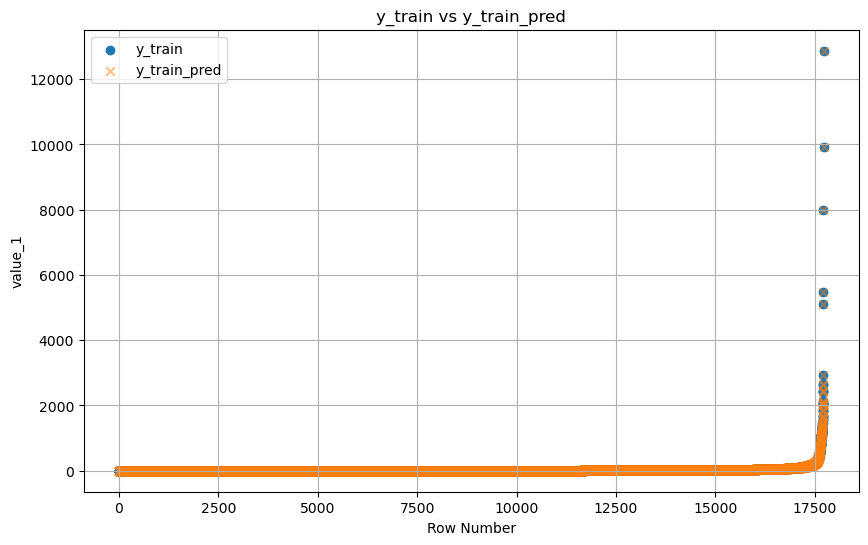

In [46]:
plotting(data, 'y_train', 'y_train_pred')

In [47]:
data.to_csv("train.csv", index=False)

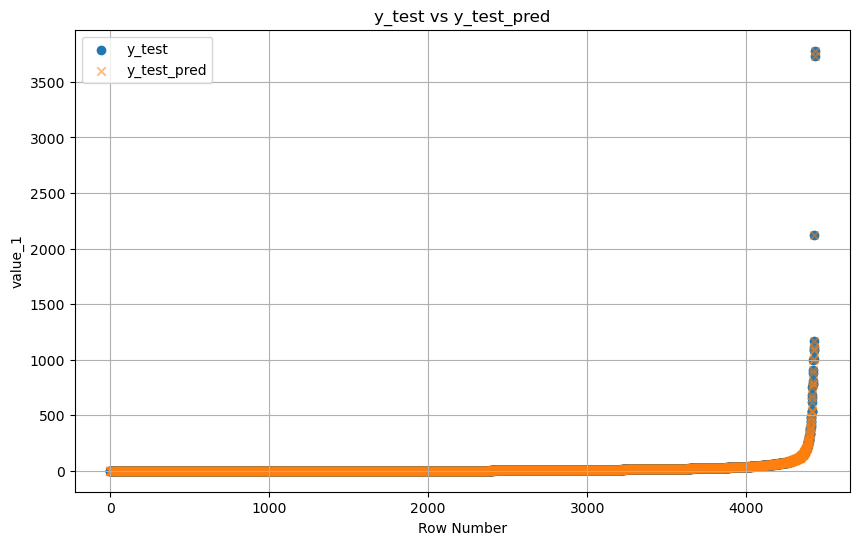

In [48]:
plotting(data_test, 'y_test', 'y_test_pred')